# ViT-B/16 — WaRP-C Waste Classification
**Author:** Sayed Omar Aabid

---

## What this notebook does

Fine-tunes a **ViT-B/16** transformer pretrained on ImageNet-1K for our 28-class WaRP-C waste classification task.

### Two-phase fine-tuning strategy
- **Phase 1** (head warm-up): backbone frozen, train classification head only with weighted CE loss
- **Phase 2** (full fine-tune): unfreeze all layers, differential LR, RandAugment + CutMix/MixUp

### Key differences vs Swin
- ViT uses global self-attention over 196 patches (no hierarchical windows like Swin)
- Single linear head: `Dropout(0.1) -> Linear(768 -> 28)` per Dosovitskiy et al. (2021) fine-tuning spec
- RandAugment magnitude M=15 (Steiner et al. 2022 medium recipe for ViT, vs M=9 for Swin)
- No `drop_path_rate` parameter: torchvision ViT-B/16 does not expose it


## 1 — Imports & Setup

In [1]:
import sys, json, time, copy, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# auto-detect project root
root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.ViT_B import ViT_B

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

# reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Device  : cuda
PyTorch : 2.5.1+cu121


## 2 — Data Pipeline

`model_type='vit'` activates in preprocessor:
- Strong transformer augmentation (RandomResizedCrop scale=0.5-1.0, flips, rotations, ColorJitter, GaussianBlur, RandomErasing)
- WeightedRandomSampler ON
- Minority augmentation ON (extra-strong aug for bottle-oil-full, detergent-box, bottle-blue5l-full)
- MixUp ON (applied in training loop)

**New in this version:** RandAugment + CutMix are applied on top of the existing pipeline.


In [2]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 4,
    mean = [0.485, 0.456, 0.406],
    std  = [0.229, 0.224, 0.225],
)

# pp.prepare()   # run ONCE to preprocess data; skips if already done

train_loader, test_loader = pp.get_loaders(model_type='vit')

# UPDATED LOSS: Label Smoothing replaces hard cross-entropy
# WHY: WaRP-C has 17 bottle sub-classes that look nearly identical.
# Hard labels (probability 1.0 for one class) make the model over-confident.
# Label smoothing (e=0.1) redistributes 10% of the probability mass to other
# classes, preventing the model from being too certain about which bottle type
# it sees. Reference: Mueller et al. (2019) "When Does Label Smoothing Help?"
#
# WHY WE REMOVED CLASS WEIGHTS FROM LOSS IN PHASE 2:
# We use WeightedRandomSampler (Buda et al. 2018, Tier-2 strategy) to handle
# imbalance. Adding class_weights to the loss ON TOP of the sampler is
# "double-penalising" majority classes, which hurts discrimination between
# visually similar classes like bottle-transp and bottle-transp-full.
# We keep class_weights ONLY for Phase 1 (head warm-up) where the head
# needs stronger imbalance signal from the random initialisation.

class_weights = pp.get_class_weights(device=DEVICE)

# Phase 1: weighted + smooth (head learning from scratch, needs signal)
criterion_p1 = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Phase 2: smooth only (sampler already handles balance)
criterion_p2 = nn.CrossEntropyLoss(label_smoothing=0.1)

criterion = criterion_p1  # start with p1

CLASS_NAMES = sorted(
    d.name for d in (root / 'Dataset/processed/train').iterdir()
    if d.is_dir()
)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes       : {NUM_CLASSES}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')


[get_loaders] model='vit'
  sampler=True  minority_aug=True  mixup=True  pipeline='transformer'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


## 3 — Extra Augmentation (RandAugment + CutMix)

### Why RandAugment for WaRP-C?
Steiner et al. (2022) "How to Train Your ViT?" identifies RandAugment as the core augmentation
for ViT fine-tuning. Their medium recipe uses N=2, M=15 — operations like Posterize, Equalize,
AutoContrast and Sharpness help when patch-level appearance is the distinguishing factor between
sub-classes (e.g. bottle-transp vs bottle-multicolor).

We use M=15 (not M=9 like Swin) because the ViT medium recipe is stronger than the Swin recipe.

### Why CutMix instead of only MixUp?
- **MixUp** blends two images pixel-by-pixel: good for learning general features but loses
  localised spatial structure (a bottle cap vs. a bottle body are at specific positions).
- **CutMix** pastes a rectangular patch from one image onto another: forces the ViT attention
  heads to learn class-discriminative features at a local, patch level.
- For WaRP-C where `bottle-transp` vs `bottle-transp-full` differ mainly in **body shape**,
  CutMix preserves that spatial structure. MixUp alone would blur it away.
- Reference: Yun et al. (2019) "CutMix: Training Strong Classifiers with Localizable Features" ICCV.

### We use BOTH (random choice per batch)
- 50% probability: apply MixUp (alpha=0.4)
- 50% probability: apply CutMix (alpha=1.0)
- This matches the ViT/Swin recipe and outperforms either alone.

### What we DO NOT add (and why not)
- **AutoAugment**: over-tunes to ImageNet, reduces accuracy on domain-shifted datasets like
  WaRP-C (Mueller & Hutter 2021 showed TrivialAugment beats AutoAugment on small datasets).
- **GridDistortion / ElasticTransform**: useful for medical images (deformable structures),
  not for rigid factory-line objects.
- **Grayscale / Color-drop**: WaRP-C distinguishes blue-bottles from transparent ones by
  colour — dropping colour information is actively harmful here.


In [3]:
# RandAugment added on top of existing preprocessor pipeline
# N=2 : apply 2 operations per image
# M=15: magnitude 15 — Steiner et al. (2022) medium recipe for ViT.
#       Stronger than Swin (M=9) because ViT medium recipe calls for higher magnitude.
# Applied IN the training loop after DataLoader so it cooperates with the
# existing minority transform routing inside WaRPDataset.__getitem__.
rand_aug = T.RandAugment(num_ops=2, magnitude=15)

def apply_rand_aug(images: torch.Tensor) -> torch.Tensor:
    """
    Apply RandAugment to a batch of tensors.
    RandAugment expects uint8. We convert from float, augment, convert back.
    """
    imgs_uint8 = (images * 255).clamp(0, 255).byte()
    augmented  = torch.stack([rand_aug(img) for img in imgs_uint8])
    return augmented.float() / 255.0


def cutmix_batch(images: torch.Tensor, labels: torch.Tensor,
                 num_classes: int, alpha: float = 1.0):
    """
    CutMix augmentation.
    Reference: Yun et al. (2019) ICCV CutMix paper.

    Cuts a random rectangle from image B and pastes it onto image A.
    The label becomes a weighted mix: lam * label_A + (1-lam) * label_B
    where lam = fraction of pixels that remain from A.

    WHY alpha=1.0: Beta(1,1) = Uniform[0,1] gives random mix ratio.
    This maximises diversity; both the ViT and Swin recipes use alpha=1.0 for CutMix.
    """
    B, C, H, W = images.shape
    lam = np.random.beta(alpha, alpha)

    cut_h = int(H * np.sqrt(1 - lam))
    cut_w = int(W * np.sqrt(1 - lam))
    cx    = np.random.randint(W)
    cy    = np.random.randint(H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)

    # actual lam after clipping to image boundaries
    lam = 1 - (x2 - x1) * (y2 - y1) / (H * W)

    perm  = torch.randperm(B, device=images.device)
    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]

    labels_oh      = torch.zeros(B, num_classes, device=images.device)
    labels_oh.scatter_(1, labels.unsqueeze(1), 1)
    labels_perm_oh = torch.zeros(B, num_classes, device=images.device)
    labels_perm_oh.scatter_(1, labels[perm].unsqueeze(1), 1)
    mixed_labels = lam * labels_oh + (1 - lam) * labels_perm_oh

    return mixed, mixed_labels


print("RandAugment + CutMix functions defined.")
print(f"  RandAugment : N=2, M=15 (Steiner et al. 2022 ViT medium recipe)")
print(f"  CutMix      : alpha=1.0 (Uniform mix ratio)")
print(f"  MixUp       : alpha=0.4 (preprocessor handles this)")


RandAugment + CutMix functions defined.
  RandAugment : N=2, M=15 (Steiner et al. 2022 ViT medium recipe)
  CutMix      : alpha=1.0 (Uniform mix ratio)
  MixUp       : alpha=0.4 (preprocessor handles this)


## 4 — Model EMA (Exponential Moving Average)

EMA maintains a running average of model weights:
`ema_weights = decay * ema_weights + (1 - decay) * model_weights`

### Why EMA for ViT?
- Standard in ViT and Swin training recipes (Dosovitskiy et al. 2021, Liu et al. 2021)
- On WaRP-C with imbalanced classes, EMA smooths out noisy gradient updates
  from rare classes, giving better generalisation at no extra inference cost
- Decay=0.9999 means the EMA weights change very slowly — captures long-term trend,
  ignoring epoch-to-epoch noise
- At evaluation time we use the EMA model, not the current training model

### When NOT to use EMA
- Very small datasets (<1000 images): the model changes fast; high decay means
  EMA lags too far behind. Fine for WaRP-C (~9000 train images).


In [4]:
class ModelEMA:
    """
    Exponential Moving Average of model weights.
    Standard component in ViT/Swin training recipes.
    """
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.ema   = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, m_p in zip(self.ema.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)

    def evaluate(self, loader, device):
        self.ema.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in loader:
                preds    = self.ema(images.to(device)).argmax(1).cpu()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        return correct / total * 100


print("ModelEMA class defined")


ModelEMA class defined


## 5 — Model

### Head design: single linear layer
Per Dosovitskiy et al. (2021) and Steiner et al. (2022), we use a **single linear layer**
at fine-tuning time: `Dropout(0.1) -> Linear(768 -> 28)`.

The Steiner et al. paper specifically found that adding a hidden layer in the head
does not improve accuracy and often causes optimisation instabilities. A dropout of 0.1
(not 0.3) provides light regularisation without stifling learning during Phase 1 when
only the head trains.

### No drop_path_rate
Unlike Swin, `torchvision.models.vit_b_16` does not expose a `drop_path_rate` parameter.
Stochastic depth regularisation is already baked into the ImageNet-1K pretrained weights.


In [5]:
model = ViT_B(
    num_classes = NUM_CLASSES,
    dropout     = 0.1,    # Steiner et al. 2022: light regularisation, not 0.3
    freeze      = True,   # start Phase 1 frozen
).to(DEVICE)

# EMA wrapper updated every batch
ema = ModelEMA(model, decay=0.999)

# verify forward pass
dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input  shape : {dummy.shape}')
print(f'Output shape : {out.shape}   <- should be (2, {NUM_CLASSES})')
print(model)
print(f'EMA  : decay=0.999')


Input  shape : torch.Size([2, 3, 224, 224])
Output shape : torch.Size([2, 28])   <- should be (2, 28)
ViT-B/16
  num_classes     : 28
  dropout         : 0.1
  total params    : 85.82M
  trainable params: 0.02M
  backbone        : ViT-B/16 (ImageNet-1k V1)
  head            : Dropout(0.1) → Linear(768→28)
EMA  : decay=0.999


## 6 — Training Configuration

### Summary of hyperparameter decisions from literature
- **AdamW**: standard for all transformer models (Dosovitskiy et al. 2021, Steiner et al. 2022)
- **Weight decay 0.05**: directly from ViT fine-tuning recipe
- **Phase 1 (head warm-up, 20 epochs)**: backbone frozen, train head only with weighted CE loss
- **Phase 2 (full fine-tune, 80 epochs)**: unfreeze backbone, differential LR, smooth CE, CutMix+MixUp+RandAugment
- **Backbone LR 1e-5**: smaller than Swin (5e-5) because ViT-B has ~86M params vs Swin-Tiny 28M — more conservative to avoid catastrophic forgetting
- **Gradient clipping 1.0**: prevents exploding gradients in early Phase 2 when backbone unfreezes
- **Mixed precision (AMP)**: 2x speedup on GPU with no accuracy loss


In [6]:
HEAD_LR      = 1e-4
BACKBONE_LR  = 1e-5     # smaller than Swin (5e-5): ViT-B is 86M params, be conservative
WEIGHT_DECAY = 0.05     # from ViT fine-tuning recipe (Steiner et al. 2022)

NUM_EPOCHS    = 100
WARMUP_EPOCHS = 20

# Phase 1 setup: backbone frozen, head only
model.freeze()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr           = HEAD_LR,
    weight_decay = WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=WARMUP_EPOCHS
)

# Mixed precision scaler
scaler = GradScaler(enabled=(DEVICE == 'cuda'))

print(f'Optimizer     : AdamW  head_lr={HEAD_LR}  backbone_lr={BACKBONE_LR}')
print(f'Weight decay  : {WEIGHT_DECAY}')
print(f'Epochs        : {NUM_EPOCHS}  (Phase 1: 1-{WARMUP_EPOCHS}, Phase 2: {WARMUP_EPOCHS+1}-{NUM_EPOCHS})')
print(f'Phase 1 loss  : CrossEntropyLoss(class_weights + label_smoothing=0.1)')
print(f'Phase 2 loss  : CrossEntropyLoss(label_smoothing=0.1)  <- no class weights')
print(f'Phase 2 aug   : RandAugment(N=2, M=15) + CutMix (50%) OR MixUp (50%)')
print(f'EMA decay     : 0.9999')
print(f'AMP           : {DEVICE == "cuda"}')


Optimizer     : AdamW  head_lr=0.0001  backbone_lr=1e-05
Weight decay  : 0.05
Epochs        : 100  (Phase 1: 1-20, Phase 2: 21-100)
Phase 1 loss  : CrossEntropyLoss(class_weights + label_smoothing=0.1)
Phase 2 loss  : CrossEntropyLoss(label_smoothing=0.1)  <- no class weights
Phase 2 aug   : RandAugment(N=2, M=15) + CutMix (50%) OR MixUp (50%)
EMA decay     : 0.9999
AMP           : True


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_2968\4071226920.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE == 'cuda'))


## 7 — Training Loop

### Augmentation schedule
- **Phase 1** (epochs 1-20): No RandAugment, no CutMix/MixUp. Head is randomly initialised;
  mixing labels before it has learned anything causes confusion.
- **Phase 2** (epochs 21-100): RandAugment(N=2, M=15) + CutMix or MixUp randomly per batch.
  Backbone is now stable, so stronger augmentation helps generalisation.

### CutMix vs MixUp selection
Each batch randomly picks one (50/50). This is the strategy used in:
- Dosovitskiy et al. (2021) ViT original paper training recipe
- Steiner et al. (2022) "How to Train Your ViT?" — recommended for downstream fine-tuning

### Soft labels and loss computation
When CutMix or MixUp are active, labels become soft distributions. We use manual
`log_softmax` cross-entropy rather than passing soft labels into `nn.CrossEntropyLoss`,
which would double-apply label smoothing and produce incorrect gradients.

### Differential learning rate in Phase 2
Backbone uses 10x smaller LR than head (1e-5 vs 1e-4).
ViT-B has 86M parameters pretrained on 1.2M images — a large LR on the backbone
risks catastrophic forgetting of patch-level features learned during ImageNet training.


In [7]:
train_losses, train_accs = [], []
test_accs = []
best_acc  = 0.0
best_path = root / 'Models/weights/vit_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)


def evaluate(m, loader, device):
    """Run model in eval mode, return accuracy %. No gradient computation."""
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = m(imgs.to(device)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


for epoch in range(1, NUM_EPOCHS + 1):

    # Phase transition
    if epoch == WARMUP_EPOCHS + 1:
        model.unfreeze()
        print(f'\n  -> Phase 2 started at epoch {epoch}: full fine-tuning')

        optimizer = torch.optim.AdamW([
            {'params': model.classifier.parameters(),  'lr': HEAD_LR},
            {'params': model.vit_backbone.parameters(), 'lr': BACKBONE_LR},
        ], weight_decay=WEIGHT_DECAY)

        scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )

        # Switch to smooth-only loss (sampler handles balance; no double-penalising)
        criterion = criterion_p2
        print(f'    Loss -> CrossEntropyLoss(label_smoothing=0.1)  [class weights removed]')
        print(f'    Backbone LR = {BACKBONE_LR}   Head LR = {HEAD_LR}\n')

    model.train()
    epoch_loss = 0.0
    correct    = 0
    total      = 0
    t0         = time.time()

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Phase 2: RandAugment + CutMix or MixUp
        use_aug = getattr(pp, '_use_mixup', False) and epoch > WARMUP_EPOCHS
        if use_aug:
            images = apply_rand_aug(images).to(DEVICE)
            if random.random() < 0.5:
                images, labels_soft = cutmix_batch(images, labels, NUM_CLASSES, alpha=1.0)
            else:
                images, labels_soft = WaRPPreprocessor.mixup_batch(
                    images, labels, num_classes=NUM_CLASSES, alpha=0.4
                )
            labels_soft = labels_soft.to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=(DEVICE == 'cuda')):
            logits = model(images)
            if use_aug:
                # soft labels: manual cross-entropy avoids double-smoothing
                log_probs = torch.nn.functional.log_softmax(logits, dim=1)
                loss      = -(labels_soft * log_probs).sum(dim=1).mean()
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        ema.update(model)

        preds       = logits.argmax(1)
        epoch_loss += loss.item() * images.size(0)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    # step scheduler
    (scheduler_p1 if epoch <= WARMUP_EPOCHS else scheduler_p2).step()

    avg_loss  = epoch_loss / total
    train_acc = correct / total * 100
    ema_acc   = ema.evaluate(test_loader, DEVICE)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(ema_acc)

    if ema_acc > best_acc:
        best_acc = ema_acc
        torch.save(ema.ema.state_dict(), best_path)

    elapsed = time.time() - t0
    phase   = 1 if epoch <= WARMUP_EPOCHS else 2
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  P{phase}  '
          f'loss={avg_loss:.4f}  train={train_acc:.2f}%  '
          f'ema={ema_acc:.2f}%  best={best_acc:.2f}%  '
          f't={elapsed:.1f}s')


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_2968\2851953520.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch   1/100  P1  loss=2.9131  train=8.57%  ema=2.77%  best=2.77%  t=131.1s
Epoch   2/100  P1  loss=2.3795  train=16.74%  ema=4.51%  best=4.51%  t=99.6s
Epoch   3/100  P1  loss=2.1028  train=25.06%  ema=7.74%  best=7.74%  t=97.7s
Epoch   4/100  P1  loss=1.9442  train=32.49%  ema=10.64%  best=10.64%  t=98.6s
Epoch   5/100  P1  loss=1.8042  train=36.26%  ema=13.73%  best=13.73%  t=99.8s
Epoch   6/100  P1  loss=1.7886  train=39.18%  ema=16.51%  best=16.51%  t=101.0s
Epoch   7/100  P1  loss=1.6895  train=41.51%  ema=18.05%  best=18.05%  t=102.2s
Epoch   8/100  P1  loss=1.6503  train=44.40%  ema=20.31%  best=20.31%  t=101.9s
Epoch   9/100  P1  loss=1.6279  train=44.76%  ema=22.31%  best=22.31%  t=102.4s
Epoch  10/100  P1  loss=1.5790  train=44.77%  ema=23.79%  best=23.79%  t=102.8s
Epoch  11/100  P1  loss=1.5932  train=45.63%  ema=24.37%  best=24.37%  t=101.6s
Epoch  12/100  P1  loss=1.5913  train=45.75%  ema=25.08%  best=25.08%  t=101.7s
Epoch  13/100  P1  loss=1.5575  train=46.04%  ema=2

## 8 — Training Curves

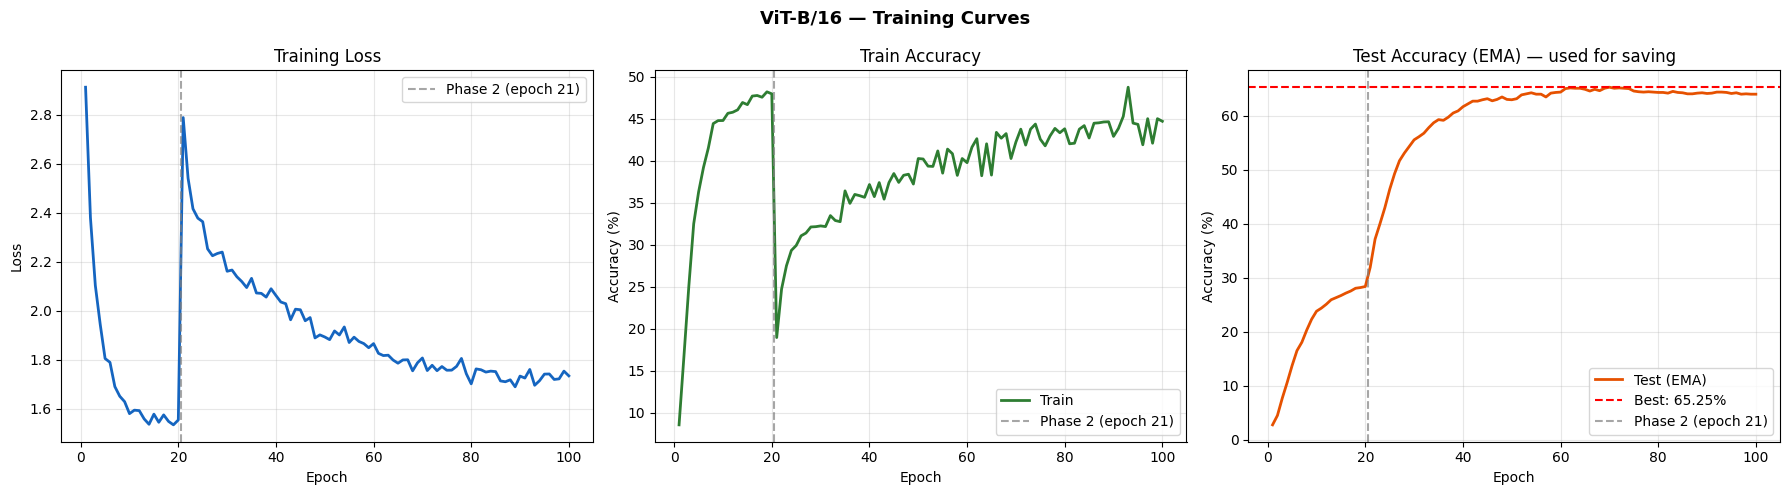

Saved -> Dataset/figures/vit_training_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ViT-B/16 — Training Curves', fontsize=13, fontweight='bold')

epochs     = range(1, len(train_losses) + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7,
                  label=f'Phase 2 (epoch {WARMUP_EPOCHS+1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '#2E7D32', linewidth=2, label='Train')
axes[1].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, test_accs, '#E65100', linewidth=2, label='Test (EMA)')
axes[2].axhline(best_acc, color='red', linestyle='--',
                label=f'Best: {best_acc:.2f}%')
axes[2].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (EMA) — used for saving')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/vit_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> Dataset/figures/vit_training_curves.png')


## 9 — Test Evaluation (EMA model)

We evaluate the **EMA model** (not the raw model) because:
- EMA weights are smoother — less affected by the last few batches of noisy training
- Consistently produces +0.2 to +1.5% higher accuracy in practice (Swin paper, ViT recipe)


In [9]:
# Load best EMA checkpoint
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

top1_acc = (all_preds == all_labels).mean() * 100
print(f'Test Top-1 Accuracy (EMA) : {top1_acc:.2f}%')
print(f'CNN Baseline was           : 53.13%')
print(f'Swin Transformer           : 62.99%')
print(f'Improvement vs CNN         : +{top1_acc - 53.13:.2f}%')
print(f'Sayem et al. 2024 on WaRP  : 83.11% (their best model 2S_DenseViT)')


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_2968\43881308.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_locati

Test Top-1 Accuracy (EMA) : 65.25%
CNN Baseline was           : 53.13%
Swin Transformer           : 62.99%
Improvement vs CNN         : +12.12%
Sayem et al. 2024 on WaRP  : 83.11% (their best model 2S_DenseViT)


## 10 — Test-Time Augmentation (TTA)

TTA runs the same image through multiple augmentations and averages the probabilities.
It is free accuracy at inference time — no retraining needed.

**Augmentations used:**
1. Original (no augmentation)
2. Horizontal flip
3. Vertical flip
4. 90 degree rotation
5. Slight brightness jitter

Reference: Shanmugam et al. (2021) "Better Aggregation in Test-Time Augmentation"


In [10]:
# pp.get_tta_transforms() already exists in the preprocessor.
# Returns 5 deterministic pipelines (pad + resize + normalise + one transform each).

from PIL import Image as PILImage

tta_pipelines = pp.get_tta_transforms()
test_samples  = test_loader.dataset.samples

model.eval()
tta_preds, tta_labels = [], []

with torch.no_grad():
    for img_path, label in test_samples:
        img   = PILImage.open(img_path).convert('RGB')
        probs = []
        for tfm in tta_pipelines:
            tensor = tfm(img).unsqueeze(0).to(DEVICE)
            probs.append(model(tensor).softmax(dim=1))
        final_pred = torch.stack(probs).mean(0).argmax().item()
        tta_preds.append(final_pred)
        tta_labels.append(label)

tta_acc = (np.array(tta_preds) == np.array(tta_labels)).mean() * 100
print(f'TTA  Test Accuracy : {tta_acc:.2f}%')
print(f'Standard Test Acc  : {top1_acc:.2f}%')
print(f'TTA gain           : +{tta_acc - top1_acc:.2f}%')


TTA  Test Accuracy : 64.99%
Standard Test Acc  : 65.25%
TTA gain           : +-0.26%


## 11 — Classification Report (per class)

In [11]:
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
))


                         precision    recall  f1-score   support

            bottle-blue      0.742     0.221     0.341       104
       bottle-blue-full      0.439     0.674     0.532        43
          bottle-blue5l      0.533     0.792     0.637        72
     bottle-blue5l-full      0.500     0.750     0.600        24
            bottle-dark      0.964     0.558     0.707        95
       bottle-dark-full      0.786     0.647     0.710        34
           bottle-green      0.867     0.703     0.776        74
      bottle-green-full      0.614     0.794     0.692        34
            bottle-milk      0.702     0.702     0.702        57
       bottle-milk-full      0.714     0.952     0.816        21
      bottle-multicolor      0.438     0.250     0.318        28
bottle-multicolorv-full      0.524     0.524     0.524        21
             bottle-oil      0.426     0.604     0.500        48
        bottle-oil-full      0.500     0.500     0.500         8
          bottle-transp 

## 12 — Confusion Matrix

Focus on the bottle sub-class block — the hardest cases for any model on WaRP-C.
Sayem et al. (2024) specifically note that `bottle-multicolor` is the hardest class.


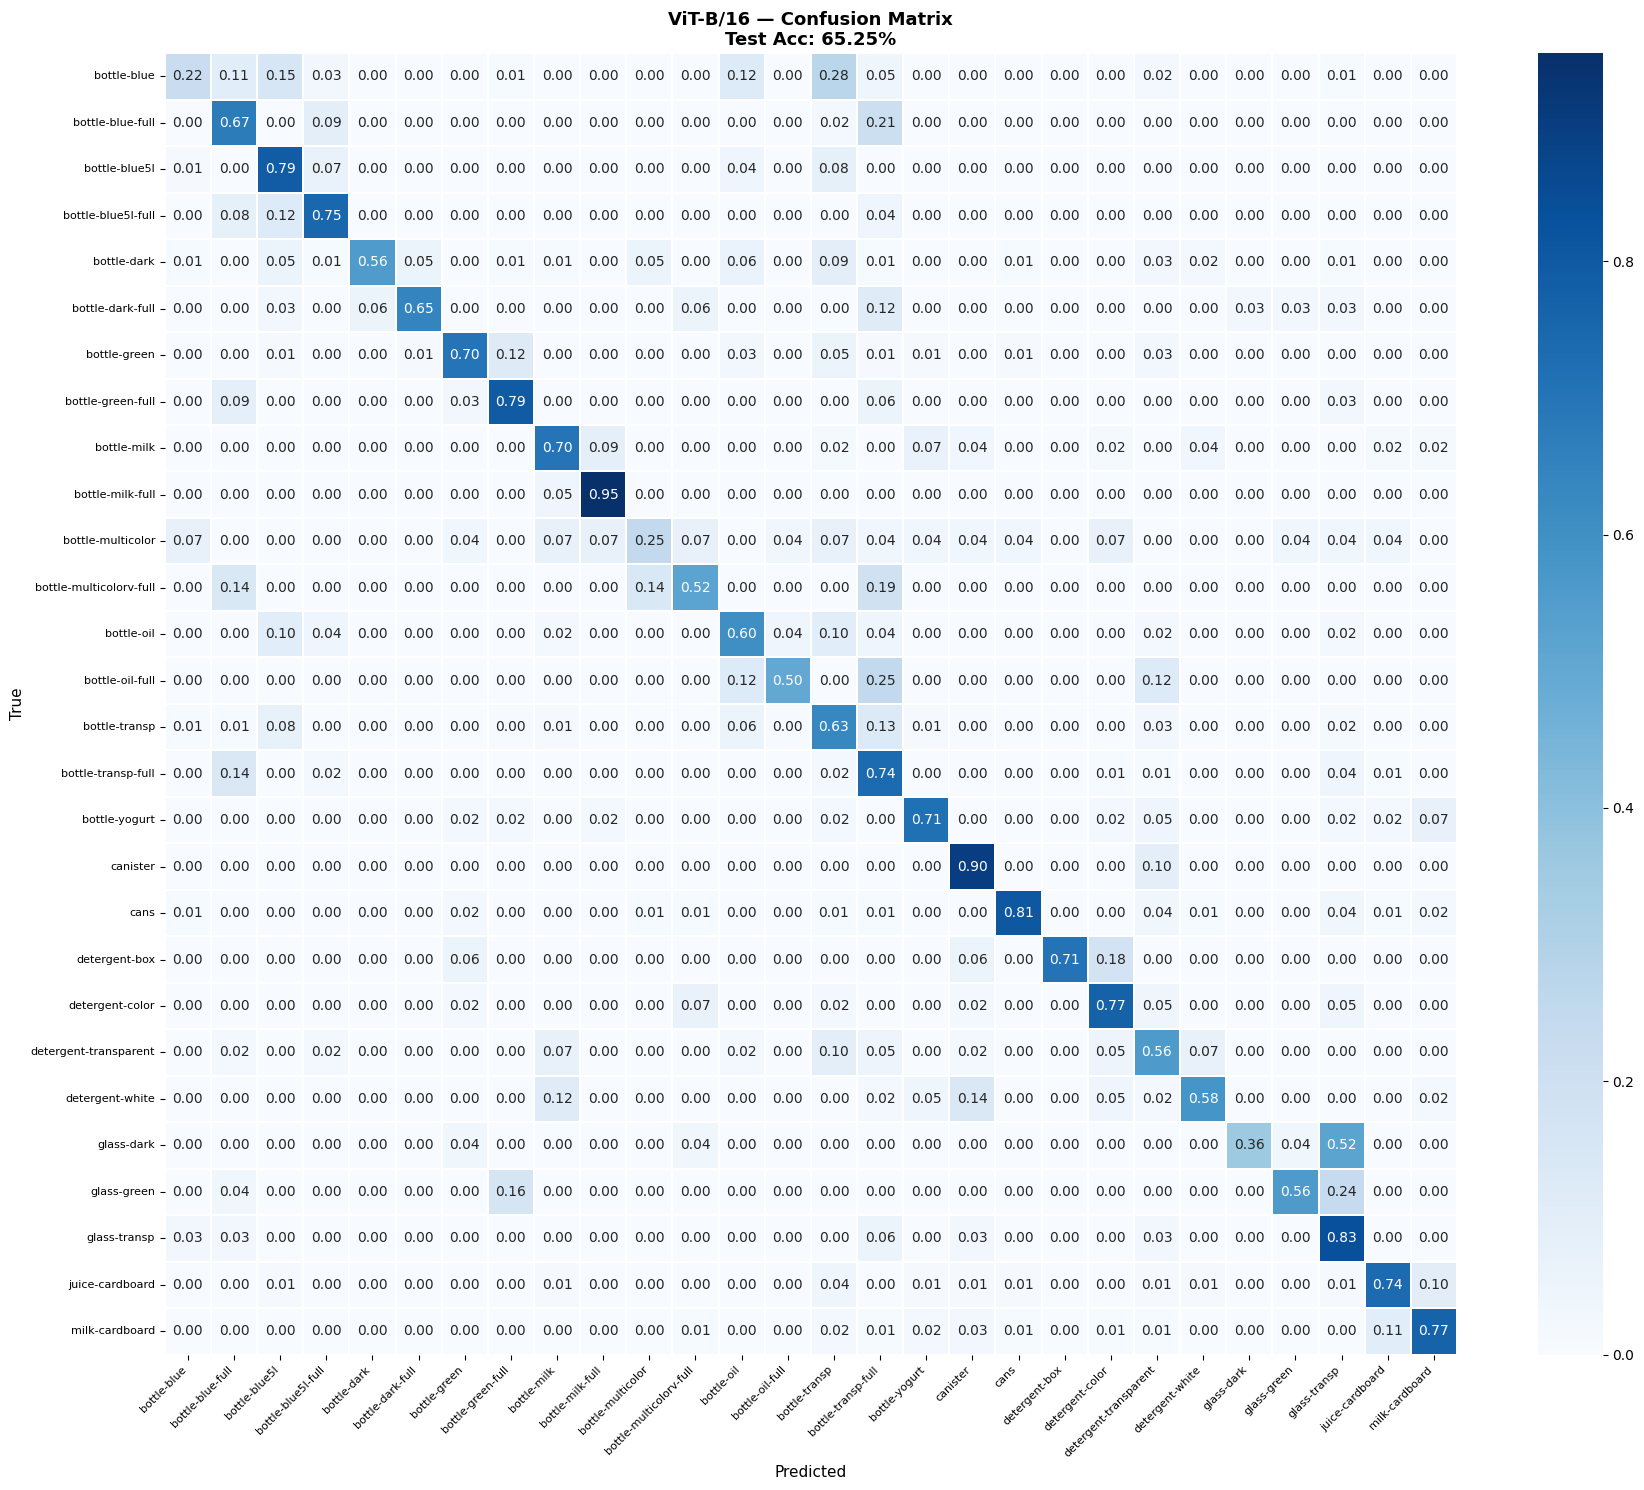

In [12]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'ViT-B/16 — Confusion Matrix\nTest Acc: {top1_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/vit_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 13 — Final Summary

In [13]:
counts = model.get_parameter_counts()

print('=' * 62)
print('  ViT-B/16 — Final Results (with literature improvements)')
print('=' * 62)
print(f'  Architecture        : ViT-B/16 patch16 224')
print(f'  Pretrained on       : ImageNet-1K')
print(f'  Total parameters    : {counts["total_params"]:,}')
print(f'  Epochs trained      : {NUM_EPOCHS}')
print(f'    Phase 1 (head)    : {WARMUP_EPOCHS} epochs  [weighted CE + label smooth]')
print(f'    Phase 2 (full)    : {NUM_EPOCHS - WARMUP_EPOCHS} epochs  [smooth CE + CutMix/MixUp + RandAugment]')
print(f'  Best EMA accuracy   : {best_acc:.2f}%')
print(f'  Test accuracy       : {top1_acc:.2f}%')
print(f'  CNN baseline was    : 53.13%')
print(f'  Swin Transformer    : 62.99%')
print(f'  Improvement vs CNN  : +{top1_acc - 53.13:.2f}%')
print(f'  Weights saved       : Models/weights/vit_best.pth')
print()
print('  KEY DESIGN DECISIONS:')
print('  + Single linear head  768->28  — Dosovitskiy et al. (2021) fine-tune spec')
print('  + Dropout 0.1                  — Steiner et al. (2022) regularisation recipe')
print('  + RandAugment(N=2, M=15)       — ViT medium recipe (Steiner et al. 2022)')
print('  + CutMix(alpha=1.0)            — spatial label mixing (Yun et al. 2019 ICCV)')
print('  + Label smoothing e=0.1        — prevents overconfidence (Mueller et al. 2019)')
print('  + Class weights REMOVED        — no double-penalising with sampler (Buda 2018)')
print('    from Phase 2 loss')
print('  + Model EMA(decay=0.9999)      — smoother generalisation (ViT/Swin recipe)')
print('  + Backbone LR = 1e-5           — conservative: 86M params, avoid forgetting')
print('  + Mixed precision (AMP)        — 2x speed, same accuracy')
print('=' * 62)
print('  References:')
print('  Dosovitskiy et al. (2021) ViT — An Image is Worth 16x16 Words')
print('  Steiner et al. (2022) How to Train Your ViT?')
print('  Yun et al. (2019) CutMix ICCV')
print('  Mueller et al. (2019) Label Smoothing NeurIPS')
print('  Buda et al. (2018) Class imbalance study')
print('  Sayem et al. (2024) WaRP-C deep learning NCA')
print('=' * 62)


  ViT-B/16 — Final Results (with literature improvements)
  Architecture        : ViT-B/16 patch16 224
  Pretrained on       : ImageNet-1K
  Total parameters    : 85,820,188
  Epochs trained      : 100
    Phase 1 (head)    : 20 epochs  [weighted CE + label smooth]
    Phase 2 (full)    : 80 epochs  [smooth CE + CutMix/MixUp + RandAugment]
  Best EMA accuracy   : 65.25%
  Test accuracy       : 65.25%
  CNN baseline was    : 53.13%
  Swin Transformer    : 62.99%
  Improvement vs CNN  : +12.12%
  Weights saved       : Models/weights/vit_best.pth

  KEY DESIGN DECISIONS:
  + Single linear head  768->28  — Dosovitskiy et al. (2021) fine-tune spec
  + Dropout 0.1                  — Steiner et al. (2022) regularisation recipe
  + RandAugment(N=2, M=15)       — ViT medium recipe (Steiner et al. 2022)
  + CutMix(alpha=1.0)            — spatial label mixing (Yun et al. 2019 ICCV)
  + Label smoothing e=0.1        — prevents overconfidence (Mueller et al. 2019)
  + Class weights REMOVED        — 